
## Experiment 4 — Mean Filter: Naive vs Shared Memory



**Objective:** This experiment implements a 2D mean-filter kernel in two ways: first using only global memory, and then using shared-memory tiling. The goal is to compare correctness and performance while studying how neighboring output pixels repeatedly reuse the same input pixels. The naive version will expose redundant global-memory reads, while the shared-memory version will load a tile of the image into fast on-chip memory so nearby threads can reuse data. The experiment focuses on 2D indexing, boundary handling, synchronization, shared-memory reuse, and the effect of reducing global-memory traffic.


## Implementation

In [1]:
!nvidia-smi

Wed Sep  9 03:07:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ninja

In [3]:
# import libraries
import torch # for pytorch
from torch.utils.cpp_extension import load_inline # for loading cuda/c++ code
import matplotlib.pyplot as plt # for plotting
import time # for cpu timing

# versions
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"cuDNN version: {torch.backends.cudnn.version()}")


PyTorch version: 2.11.0+cu128
CUDA available: True
cuDNN version: 91900


In [4]:
cpp_source = """

#include <torch/extension.h>

// naive mean filter prototype with signature
torch::Tensor naive_mean_filter(torch::Tensor image, int radius);
// shared memory mean filter prototype with signature
torch::Tensor shared_mean_filter(torch::Tensor image, int radius);



"""

cuda_source ="""

#include <torch/extension.h>
#include <cstdint>


// Building kernels for naive and shared memory mean filter
// naive mean filter kernel

/*

In the naive mean filter kernel, we will iterate over the image and compute the mean of the surrounding pixels.

We will use the following parameters:
- @param image_ptr: pointer to the image
- @param output_ptr: pointer to the output
- @param width: width of the image
- @param height: height of the image
- @param radius: radius of the mean filter

An important point to note that even though we are using a 2D image, 
the image is stored at memory as a 1D array, and CUDA kernels operate on 1D arrays instead of tensors.

Now to solve the problem: here are the steps:

1. A single thread corresponds to a single output pixel.
- We need to pick the exact row and col from the block dim2 values to compute the output pixel global index.
2. We need to use the radius around the input index at tid to compute the mean of the surrounding pixels, ensure the mean is within bounds only.
3. In order to do this effectively, we need to get the row and column of the output pixel, 
   and then use the radius to compute the mean of the surrounding input pixels in a loop.
*/

__global__ void naive_mean_filter_kernel(
    const uint8_t* image_ptr, 
    uint8_t* output_ptr, 
    int width, int height, 
    int radius
){
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    int tid = row * width + col;

    int sum = 0;
    int count = 0;

    // ensure the output is within bounds
    if (row <height && col < width){
        // 2D kernel loop to compute the mean of the surrounding pixels
        for (int i = -radius; i <= radius; i++){
            for (int j = -radius; j <= radius; j++){
                int input_row = row + i;
                int input_col = col + j;
                // ensure the input is within bounds only
                if (input_row >= 0 && input_row < height && input_col >= 0 && input_col < width){
                    int input_index = input_row * width + input_col;
                    sum += image_ptr[input_index];
                    count++;
                }
            }
        }
        // compute the mean of the surrounding pixels
        if (count > 0){
            output_ptr[tid] = sum / count;
        }
        else{
            output_ptr[tid] = 0;
        }
    }
    
}

// shared memory mean filter kernel

/*




*/

__global__ void shared_mean_filter_kernel(
    const uint8_t* image_ptr, 
    uint8_t* output_ptr, 
    int width, int height, 
    int radius
){

    // Step 1: get the block start row and col for the output pixel
    // And then from the extract the local thread index for the output pixel
    int out_row = blockIdx.y * blockDim.y + threadIdx.y;
    int out_col = blockIdx.x * blockDim.x + threadIdx.x;
    int local_tid = threadIdx.y * blockDim.x + threadIdx.x;

    // Step 2: plan for the shared memory
    extern __shared__ uint8_t shared_mem[];
    int shared_mem_dims = (blockDim.x + 2*radius) * (blockDim.y + 2*radius);
    

    // Step 3: fill the shared memory from the input
    for (int idx = local_tid; idx < shared_mem_dims; idx += blockDim.x * blockDim.y){
        int shared_row = idx / (blockDim.x + 2*radius);
        int shared_col = idx % (blockDim.x + 2*radius);
        int shared_index = shared_row * (blockDim.x + 2*radius) + shared_col;
        
        int global_row = blockIdx.y * blockDim.y + shared_row - radius;
        int global_col = blockIdx.x * blockDim.x + shared_col - radius;
        if (global_row >= 0 && global_row < height && global_col >= 0 && global_col < width){
            int global_index = global_row * width + global_col;
            shared_mem[shared_index] = image_ptr[global_index];
        }
        else{
            shared_mem[shared_index] = 0;
        }
    }

    __syncthreads();//ensure that all the threads have finished writing to the shared memory before continuing

    // Step 4: compute the mean of the surrounding pixels
    if (out_row < height && out_col < width){
        int sum = 0;
        int count = 0;
        for (int i = -radius; i <= radius; i++){
            for (int j = -radius; j <= radius; j++){
                // but we need the global row and col to be within bounds so that we can access the shared memory
                int global_row = out_row + i ;
                int global_col = out_col + j ;
                if (global_row >= 0 && global_row < height && global_col >= 0 && global_col < width){
                    int shared_index = (threadIdx.y + radius + i) * (blockDim.x + 2*radius) + (threadIdx.x + radius + j);
                    sum += shared_mem[shared_index];
                    count++;
                }
                
            }
        }
        int out_tid = (blockIdx.y * blockDim.y + threadIdx.y) * width + (blockIdx.x * blockDim.x + threadIdx.x);
        if (count > 0){
            output_ptr[out_tid] = sum / count;
        }
        else{
            output_ptr[out_tid] = 0;
        }
    }
    
}    

// Building launchers for naive and shared memory mean filter

/*

Every launcher of a kernel should follow the standard procedure:

- Implement Checks before launching the respective kernels
- Match and also ensure proper parameters are passed to the kernel
- Build the right grid/block configuration
- Launch the kernels
- Synchronize the device
- Copy the result back to the host
- Return the result

In this circumstance, we have 2 kernels to launch: naive_mean_filter_kernel and shared_mean_filter_kernel. Here's our procedure we will strive to follow:
1. Checks to be Implemented
- Check if the image is a 2D tensor
- Check if the radius is a positive integer
- Check if the image is on the GPU
- Check if the dtype of the image is FP32
2. Parameters to be Passed to the Kernel
- Image pointer
- Output pointer
- Width of the image
- Height of the image
- Radius int value
3. Grid/Block Configuration to be Built
- Now we will try to use a 2d block configuration to launch the kernels.
- We will use the width and height of the image to build the grid configuration.
4. Launch the Kernels
- Launch the naive_mean_filter_kernel and shared_mean_filter_kernel with the above parameters.alignas
5. Synchronize the Device
- Synchronize the device after launching the kernels.
6. Return the Result
- Return the result.
*/

// naive mean filter launcher
torch::Tensor naive_mean_filter(torch::Tensor image, int radius){
    // 1. Checks to be Implemented
    TORCH_CHECK(image.dim() == 2, "Image must be a 2D tensor");
    TORCH_CHECK(radius > 0, "Radius must be a positive integer");
    TORCH_CHECK(image.device().is_cuda(), "Image must be on the GPU");
    TORCH_CHECK(image.dtype() == torch::kUInt8, "Image must be a uint8 tensor");
    // 2. Parameters to be Passed to the Kernel
    torch::Tensor output = torch::empty_like(image, image.options()); //ensure that the output tensor is on the same device as the image
    const uint8_t* image_ptr = image.data_ptr<uint8_t>();
    uint8_t* output_ptr = output.data_ptr<uint8_t>(); //dataptr ensures that 
    int width = image.size(1);
    int height = image.size(0);
    // 3. Grid/Block Configuration to be Built
    dim3 block(16, 16);
    dim3 grid((width + block.x - 1) / block.x, (height + block.y - 1) / block.y);
    // 4. Launch the Kernels
    naive_mean_filter_kernel<<<grid, block>>>(image_ptr, output_ptr, width, height, radius);
    // 5. Return the Result
    return output;
}

// shared memory mean filter launcher
torch::Tensor shared_mean_filter(torch::Tensor image, int radius){
    // 1. Checks to be Implemented
    TORCH_CHECK(image.dim() == 2, "Image must be a 2D tensor");
    TORCH_CHECK(radius > 0, "Radius must be a positive integer");
    TORCH_CHECK(image.device().is_cuda(), "Image must be on the GPU");
    TORCH_CHECK(image.dtype() == torch::kUInt8, "Image must be a uint8 tensor");
    // 2. Parameters to be Passed to the Kernel
    torch::Tensor output = torch::empty_like(image, image.options()); //ensure that the output tensor is on the same device as the image
    const uint8_t* image_ptr = image.data_ptr<uint8_t>();
    uint8_t* output_ptr = output.data_ptr<uint8_t>(); //dataptr ensures that 
    int width = image.size(1);
    int height = image.size(0);
    // 3. Grid/Block Configuration to be Built
    dim3 block(16, 16);
    dim3 grid((width + block.x - 1) / block.x, (height + block.y - 1) / block.y);
    size_t shared_mem_size = (block.x+2*radius) * (block.y+2*radius) * sizeof(uint8_t);
    // 4. Launch the Kernels
    shared_mean_filter_kernel<<<grid, block, shared_mem_size>>>(image_ptr, output_ptr, width, height, radius);
    // 5. Return the Result
    return output;
}
"""


In [5]:

module = load_inline(
    name="mean_filter_v4",
    cpp_sources=cpp_source,
    cuda_sources=cuda_source,
    functions=["naive_mean_filter", "shared_mean_filter"],
    extra_cuda_cflags=["-O3"],
    extra_cflags=["-O3"]
)


### Benchmarking

In [8]:
# benchmark_mean_filter_ncu.py

# Assumes your extension module was already built/importable.
# If using load_inline inside the same script, place that above this section.

WIDTH = 4096
HEIGHT = 4096
RADIUS = 1
RUNS = 100
image = torch.randint(
    0,
    256,
    (HEIGHT, WIDTH),
    dtype=torch.uint8,
    device="cuda"
)

# Warmup
for _ in range(10):
    out_naive = module.naive_mean_filter(image, RADIUS)
    out_shared = module.shared_mean_filter(image, RADIUS)

torch.cuda.synchronize()
naive_time = 0
shared_time = 0
for _ in range(RUNS):

    # Profile target kernels
    start_cuda = torch.cuda.Event(enable_timing=True)
    end_cuda = torch.cuda.Event(enable_timing=True)
    start_shared = torch.cuda.Event(enable_timing=True)
    end_shared = torch.cuda.Event(enable_timing=True)

    start_cuda.record()
    out_naive = module.naive_mean_filter(image, RADIUS)
    end_cuda.record()
    torch.cuda.synchronize()
    naive_time += start_cuda.elapsed_time(end_cuda)

    start_shared.record()
    out_shared = module.shared_mean_filter(image, RADIUS)
    end_shared.record()
    torch.cuda.synchronize()
    shared_time += start_shared.elapsed_time(end_shared)

print(f"Average time for naive mean filter: {naive_time/RUNS} ms")
print(f"Average time for shared mean filter: {shared_time/RUNS} ms")

print("done")

Average time for naive mean filter: 1.3456838369369506 ms
Average time for shared mean filter: 1.4004736018180848 ms
done


In [9]:
print("out_naive==out_shared?: ", torch.allclose(out_naive, out_shared))

out_naive==out_shared?:  True


In [10]:
naive_time, shared_time

(134.56838369369507, 140.04736018180847)

## Observations

In [11]:
!ncu --query-metrics | grep -i dram

dram__bytes                                                                 Counter         byte            # of bytes accessed in DRAM                                           
dram__bytes_read                                                            Counter         byte            # of bytes read from DRAM                                             
dram__bytes_write                                                           Counter         byte            # of bytes written to DRAM                                            
dram__cycles_active                                                         Counter         cycle           # of cycles where DRAM was active                                     
dram__cycles_active_read                                                    Counter         cycle           # of cycles where DRAM was active for reads                           
dram__cycles_active_write                                                   Counter         cycle        

In [12]:
!ncu --query-metrics | grep -i global_op_ld

l1tex__average_t_sectors_per_request_pipe_lsu_mem_global_op_ld              Ratio           sector          average # of sectors requested per request sent to T stage for global 
l1tex__data_bank_conflicts_pipe_lsu_mem_global_op_ld                        Counter                         # of data bank conflicts generated by global loads                    
l1tex__t_bytes_pipe_lsu_mem_global_op_ld                                    Counter         byte            # of bytes requested for global loads                                 
l1tex__t_bytes_pipe_lsu_mem_global_op_ld_lookup_hit                         Counter         byte            # of bytes requested with tag-hit and data-hit for global loads       
l1tex__t_bytes_pipe_lsu_mem_global_op_ld_lookup_miss                        Counter         byte            # of bytes requested that missed for global loads                     
l1tex__t_output_wavefronts_pipe_lsu_mem_global_op_ld                        Counter                      

In [13]:
!ncu --query-metrics | grep -i shared

l1tex__data_bank_conflicts_pipe_lsu_mem_shared                              Counter                         # of shared memory data bank conflicts generated by LDS, LD, LDSM, 3D 
l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_atom                      Counter                         # of shared memory data bank conflicts generated by ATOMS, ATOM       
l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_ld                        Counter                         # of shared memory data bank conflicts generated by LDS, LD, 3D       
l1tex__data_bank_conflicts_pipe_lsu_mem_shared_op_st                        Counter                         # of shared memory data bank conflicts generated by STS, ST, 3D       
l1tex__data_pipe_lsu_wavefronts                                             Counter                         # of local/global/shared + surface write wavefronts processed by      
l1tex__data_pipe_lsu_wavefronts_cmd_read                                    Counter                      

In [18]:
def write_script_to_file(script, filename):
    with open(filename, 'w') as f:
        f.write(script)

write_script_to_file(cpp_source, 'mean_filter.cpp')
write_script_to_file(cuda_source, 'mean_filter_cuda.cu')

In [22]:
# write benchmark file for ncu to read from a string
benchmark_script = """

import argparse
import torch
from pathlib import Path
from torch.utils.cpp_extension import load_inline


# -------------------------
# Command-line arguments
# -------------------------
parser = argparse.ArgumentParser()

parser.add_argument("--width", type=int, default=4096)
parser.add_argument("--height", type=int, default=4096)
parser.add_argument("--radius", type=int, default=1)
parser.add_argument("--runs", type=int, default=1)
parser.add_argument("--warmup", type=int, default=5)

parser.add_argument(
    "--kernel",
    choices=["naive", "shared", "both"],
    default="both"
)

args = parser.parse_args()


# -------------------------
# Load CUDA extension
# -------------------------
cpp_source = Path("mean_filter.cpp").read_text()
cuda_source = Path("mean_filter_cuda.cu").read_text()

module = load_inline(
    name="mean_filter_ncu",
    cpp_sources=cpp_source,
    cuda_sources=cuda_source,
    functions=[
        "naive_mean_filter",
        "shared_mean_filter",
    ],
    extra_cflags=["-O3"],
    extra_cuda_cflags=["-O3", "-lineinfo"],
    verbose=False,
)


# -------------------------
# Input
# -------------------------
image = torch.randint(
    0,
    256,
    (args.height, args.width),
    dtype=torch.uint8,
    device="cuda",
)


# -------------------------
# Warmup
# -------------------------
for _ in range(args.warmup):

    if args.kernel in ["naive", "both"]:
        module.naive_mean_filter(image, args.radius)

    if args.kernel in ["shared", "both"]:
        module.shared_mean_filter(image, args.radius)

torch.cuda.synchronize()


# -------------------------
# Profile target launches
# -------------------------
for _ in range(args.runs):

    if args.kernel in ["naive", "both"]:
        module.naive_mean_filter(image, args.radius)

    if args.kernel in ["shared", "both"]:
        module.shared_mean_filter(image, args.radius)

torch.cuda.synchronize()


print(
    f"width={args.width}, "
    f"height={args.height}, "
    f"radius={args.radius}, "
    f"runs={args.runs}, "
    f"warmup={args.warmup}, "
    f"kernel={args.kernel}"
)
"""

In [23]:
write_script_to_file(benchmark_script, 'benchmark_mean_filter_ncu.py')

In [24]:
!ls

benchmark_mean_filter_ncu.py  mean_filter.cpp  mean_filter_cuda.cu  sample_data


In [25]:
!python benchmark_mean_filter_ncu.py \
    --width 4096 \
    --height 4096 \
    --radius 3 \
    --runs 1 \
    --warmup 5 \
    --kernel shared

width=4096, height=4096, radius=3, runs=1, warmup=5, kernel=shared


In [42]:
import subprocess
import pandas as pd
import io

WIDTH = 4096
HEIGHT = 4096

RUNS = 10
WARMUP = 5

RADII = [1, 2, 3, 5, 7]
KERNELS = ["naive", "shared"]

METRICS = [
    "gpu__time_duration.sum",
    "dram__bytes_read.sum",
    "l1tex__t_bytes_pipe_lsu_mem_global_op_ld.sum",
    "sm__sass_data_bytes_mem_shared_op_ld.sum",
    "sm__sass_data_bytes_mem_shared_op_st.sum",
]

SHARED_METRICS = [
    "sm__sass_data_bytes_mem_shared_op_ld.sum",
    "sm__sass_data_bytes_mem_shared_op_st.sum",
]

all_rows = []


def clean_numeric(series):
    """
    Convert NCU CSV values such as:
        "12,345"
        "N/A"
        ""
    into numeric values.
    """
    return pd.to_numeric(
        series
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace({
            "N/A": None,
            "nan": None,
            "": None,
        }),
        errors="coerce",
    )


for radius in RADII:

    for kernel in KERNELS:

        kernel_name = (
            "naive_mean_filter_kernel"
            if kernel == "naive"
            else "shared_mean_filter_kernel"
        )

        print(
            f"Profiling {kernel}, "
            f"radius={radius}"
        )

        cmd = [
            "ncu",

            "--csv",
            "--page", "raw",

            "--metrics",
            ",".join(METRICS),

            # Ignore warmup launches
            "--launch-skip",
            str(WARMUP),

            # Profile exactly RUNS launches
            "--launch-count",
            str(RUNS),

            "--kernel-name",
            f"regex:{kernel_name}",

            "python",
            "benchmark_mean_filter_ncu.py",

            "--width", str(WIDTH),
            "--height", str(HEIGHT),
            "--radius", str(radius),
            "--runs", str(RUNS),
            "--warmup", str(WARMUP),
            "--kernel", kernel,
        ]

        result = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
        )

        if result.returncode != 0:
            print("NCU FAILED:")
            print(result.stderr)
            continue

        raw_output = (
            result.stdout
            + "\n"
            + result.stderr
        )

        lines = raw_output.splitlines()

        # ------------------------------------------------
        # Find NCU raw CSV header
        # ------------------------------------------------

        header_idx = None

        for i, line in enumerate(lines):

            if line.startswith(
                '"ID","Process ID"'
            ):
                header_idx = i
                break

        if header_idx is None:

            print(
                "Could not find NCU CSV header:",
                kernel,
                radius,
            )

            continue

        csv_text = "\n".join(
            lines[header_idx:]
        )

        try:

            ncu_df = pd.read_csv(
                io.StringIO(csv_text)
            )

        except Exception as e:

            print(
                "CSV parse failed:",
                e
            )

            continue

        if ncu_df.empty:

            print(
                "No NCU rows:",
                kernel,
                radius,
            )

            continue


        # ------------------------------------------------
        # DEBUG: show how many launches NCU captured
        # ------------------------------------------------

        print(
            f"  NCU kernel rows: {len(ncu_df)}"
        )


        # ------------------------------------------------
        # Convert every requested metric to numeric
        # ------------------------------------------------

        for metric in METRICS:

            if metric not in ncu_df.columns:

                print(
                    f"  Missing metric: {metric}"
                )

                continue

            ncu_df[metric] = clean_numeric(
                ncu_df[metric]
            )


        # ------------------------------------------------
        # Build one row for this experimental condition
        #
        # We average across the RUNS profiled launches.
        # ------------------------------------------------

        result_row = {
            "width": WIDTH,
            "height": HEIGHT,
            "radius": radius,
            "runs": RUNS,
            "warmup": WARMUP,
            "kernel": kernel,
        }


        for metric in METRICS:

            if metric not in ncu_df.columns:
                result_row[metric] = float("nan")
                continue

            values = (
                ncu_df[metric]
                .dropna()
            )

            if len(values) > 0:

                result_row[metric] = (
                    values.mean()
                )

            else:

                # Naive kernel has no explicit
                # shared-memory operations.
                if (
                    kernel == "naive"
                    and metric in SHARED_METRICS
                ):
                    result_row[metric] = 0.0

                else:
                    result_row[metric] = float("nan")


        all_rows.append(
            result_row
        )


# ============================================================
# Final dataframe
# ============================================================

df = pd.DataFrame(all_rows)

print("\nFINAL RESULTS")
display(df)

print("\nNULL COUNTS")
print(df.isna().sum())


df.to_csv(
    "mean_filter_ncu_results.csv",
    index=False,
)

print(
    "\nSaved: "
    "mean_filter_ncu_results.csv"
)

Profiling naive, radius=1
  NCU kernel rows: 11
Profiling shared, radius=1
  NCU kernel rows: 11
Profiling naive, radius=2
  NCU kernel rows: 11
Profiling shared, radius=2
  NCU kernel rows: 11
Profiling naive, radius=3
  NCU kernel rows: 11
Profiling shared, radius=3
  NCU kernel rows: 11
Profiling naive, radius=5
  NCU kernel rows: 11
Profiling shared, radius=5
  NCU kernel rows: 11
Profiling naive, radius=7
  NCU kernel rows: 11
Profiling shared, radius=7
  NCU kernel rows: 11

FINAL RESULTS


,width,height,radius,runs,warmup,kernel,gpu__time_duration.sum,dram__bytes_read.sum,l1tex__t_bytes_pipe_lsu_mem_global_op_ld.sum,sm__sass_data_bytes_mem_shared_op_ld.sum,sm__sass_data_bytes_mem_shared_op_st.sum
0,4096,4096,1,10,5,naive,1826860.8,70436265.6,4.015190e+08,0.000000e+00,0.0
1,4096,4096,1,10,5,shared,1935462.4,69275116.8,9.166196e+07,1.509458e+08,21233664.0
2,4096,4096,2,10,5,naive,2854192.0,74990732.8,1.171112e+09,0.000000e+00,0.0
3,4096,4096,2,10,5,shared,3127744.0,74095180.8,1.025180e+08,4.191847e+08,26214400.0
4,4096,4096,3,10,5,naive,5027196.8,79021824.0,2.341867e+09,0.000000e+00,0.0
5,4096,4096,3,10,5,shared,4653372.8,77368864.0,1.187663e+08,8.213956e+08,31719424.0
6,4096,4096,5,10,5,naive,11195353.6,81435312.0,5.886679e+09,0.000000e+00,0.0
7,4096,4096,5,10,5,shared,9571564.8,78992796.8,1.473337e+08,2.027341e+09,44302336.0
8,4096,4096,7,10,5,naive,20612291.2,82267129.6,1.103488e+10,0.000000e+00,0.0
9,4096,4096,7,10,5,shared,16509913.6,80327184.0,1.739890e+08,3.767995e+09,58982400.0



NULL COUNTS
width                                           0
height                                          0
radius                                          0
runs                                            0
warmup                                          0
kernel                                          0
gpu__time_duration.sum                          0
dram__bytes_read.sum                            0
l1tex__t_bytes_pipe_lsu_mem_global_op_ld.sum    0
sm__sass_data_bytes_mem_shared_op_ld.sum        0
sm__sass_data_bytes_mem_shared_op_st.sum        0
dtype: int64

Saved: mean_filter_ncu_results.csv


In [43]:
!pip install pandas

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Load results
# ============================================================

df = pd.read_csv("mean_filter_ncu_results.csv")

# Metric names
TIME = "gpu__time_duration.sum"
DRAM_READ = "dram__bytes_read.sum"
GLOBAL_READ = "l1tex__t_bytes_pipe_lsu_mem_global_op_ld.sum"
SHARED_LOAD = "sm__sass_data_bytes_mem_shared_op_ld.sum"

# Ensure numeric
metric_cols = [
    TIME,
    DRAM_READ,
    GLOBAL_READ,
    SHARED_LOAD,
]

for col in metric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Sort by radius
df = df.sort_values(["radius", "kernel"])

naive = df[df["kernel"] == "naive"].sort_values("radius")
shared = df[df["kernel"] == "shared"].sort_values("radius")

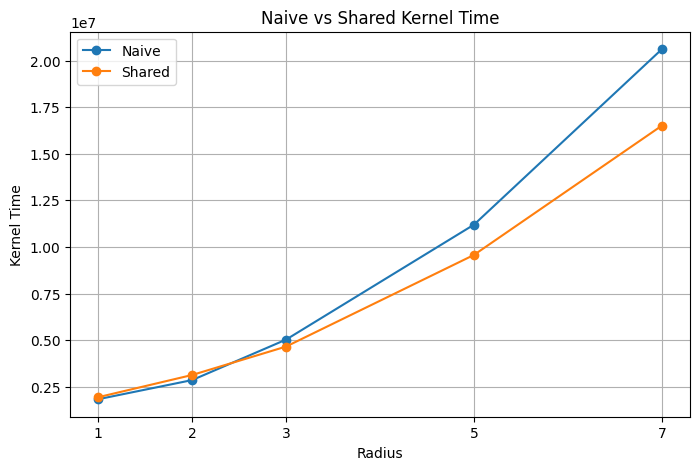

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(
    naive["radius"],
    naive[TIME],
    marker="o",
    label="Naive"
)

plt.plot(
    shared["radius"],
    shared[TIME],
    marker="o",
    label="Shared"
)

plt.xlabel("Radius")
plt.ylabel("Kernel Time")
plt.title("Naive vs Shared Kernel Time")

plt.xticks(sorted(df["radius"].unique()))
plt.grid(True)
plt.legend()
plt.show()

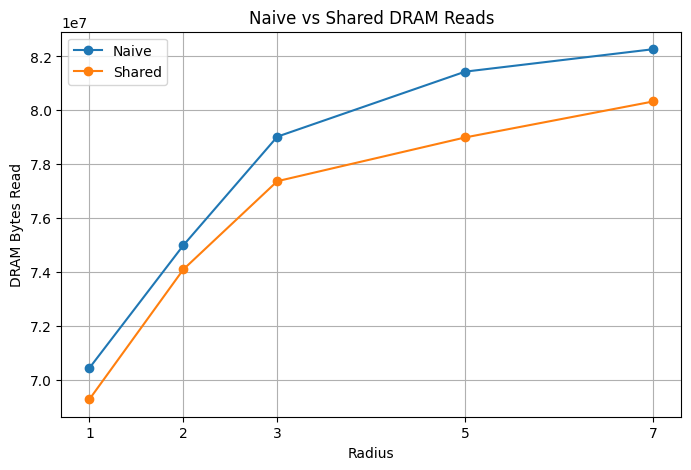

In [46]:
plt.figure(figsize=(8, 5))

plt.plot(
    naive["radius"],
    naive[DRAM_READ],
    marker="o",
    label="Naive"
)

plt.plot(
    shared["radius"],
    shared[DRAM_READ],
    marker="o",
    label="Shared"
)

plt.xlabel("Radius")
plt.ylabel("DRAM Bytes Read")
plt.title("Naive vs Shared DRAM Reads")

plt.xticks(sorted(df["radius"].unique()))
plt.grid(True)
plt.legend()
plt.show()

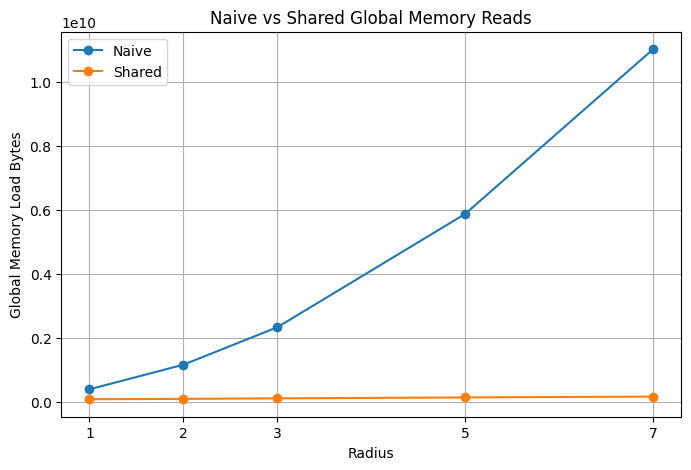

In [47]:
plt.figure(figsize=(8, 5))

plt.plot(
    naive["radius"],
    naive[GLOBAL_READ],
    marker="o",
    label="Naive"
)

plt.plot(
    shared["radius"],
    shared[GLOBAL_READ],
    marker="o",
    label="Shared"
)

plt.xlabel("Radius")
plt.ylabel("Global Memory Load Bytes")
plt.title("Naive vs Shared Global Memory Reads")

plt.xticks(sorted(df["radius"].unique()))
plt.grid(True)
plt.legend()
plt.show()

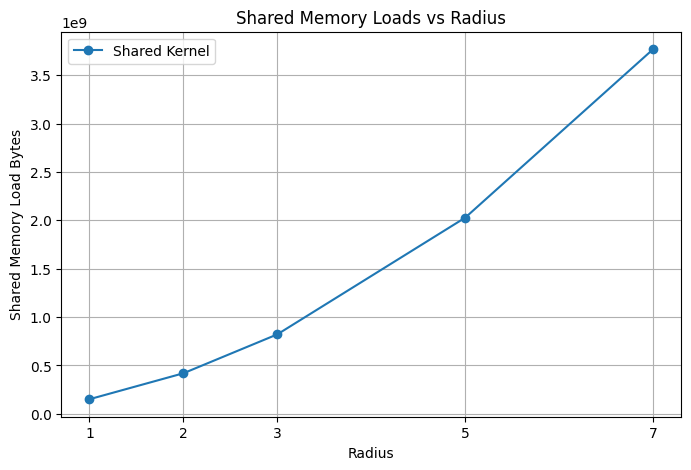

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(
    shared["radius"],
    shared[SHARED_LOAD],
    marker="o",
    label="Shared Kernel"
)

plt.xlabel("Radius")
plt.ylabel("Shared Memory Load Bytes")
plt.title("Shared Memory Loads vs Radius")

plt.xticks(sorted(df["radius"].unique()))
plt.grid(True)
plt.legend()
plt.show()


- At small radii, the shared-memory kernel is not automatically faster because it introduces extra overhead from cooperative tile loading, shared-memory accesses, indexing, and `__syncthreads()`.

- As the radius increases, the shared-memory kernel becomes increasingly faster than the naive implementation. This shows that shared-memory tiling becomes more beneficial when the amount of neighborhood reuse increases.

- DRAM reads are slightly lower for the shared-memory kernel across the tested radii, but the difference is relatively small. This suggests that the GPU cache hierarchy is already absorbing many repeated reads from the naive implementation.

- The strongest difference appears in global-memory load traffic. The naive kernel's global-memory reads increase rapidly as radius grows because every thread independently reloads a larger overlapping neighborhood.

- The shared-memory kernel keeps global-memory load traffic much lower because each block cooperatively loads an input tile and halo once, then reuses those values for multiple output threads.

- Shared-memory load traffic increases significantly with radius. This is expected because more of the neighborhood computation is being served from shared memory instead of repeatedly accessing global memory.

- Therefore, increasing the radius shifts more memory traffic from global memory toward shared memory.

- The experiment demonstrates that reducing global-memory traffic does not necessarily produce an immediate speedup at small radii. The benefit appears once the amount of data reuse becomes large enough to outweigh the synchronization and shared-memory management overhead.



## Conclusion



Shared-memory tiling is most useful when neighboring threads have substantial overlapping data reuse. As the mean-filter radius increases, the naive kernel performs increasingly redundant global-memory accesses, while the shared-memory kernel reuses a cooperatively loaded tile. This reduction in global-memory traffic eventually outweighs the additional shared-memory and synchronization overhead, resulting in better kernel performance.